In [3]:
from google.colab import drive
drive.mount("/content/drive")
%cd /content/drive/MyDrive/Analytics/Data/E-com Brazil

Mounted at /content/drive
/content/drive/MyDrive/Analytics/Data/E-com Brazil


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#Uploading and checking data
br_data = pd.read_csv("Brazil_dataset_update.csv")
br_data.head()

,order_id,order_item_id,customer_id,order_purchase_timestamp,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,seller_id,price,shipping_limit_date,freight_value,product_category_name,average_review_rate,customer_city,customer_state
0,7254ba1421bac35de5d5da660715bf0e,1,65e1faa1535d1b4ca089fd7b9e84b5b3,2016-10-07 22:46:51 UTC,2016-10-26 11:41:50 UTC,2016-10-28 12:11:38 UTC,2016-12-01 00:00:00 UTC,d03698c2efd04a549382afa6623e27fb,161.55,2016-10-11 22:59:24 UTC,15.30,computers_accessories,5.0,nossa senhora da gloria,SE
1,80606b26965c5ed21e85a085e0667b63,1,9e241a9965210ac822859a94c0f33162,2016-10-04 11:03:14 UTC,2016-11-17 11:21:15 UTC,2016-11-17 19:14:41 UTC,2016-12-08 00:00:00 UTC,77530e9772f57a62c906e1c21538ab82,148.00,2016-10-10 07:46:47 UTC,30.11,furniture_decor,5.0,parnamirim,RN
2,4421f094ff828b78aba6d18db005821d,1,497444aa14246e71ed88c2c37540ddfb,2016-10-10 10:22:55 UTC,2016-10-14 12:02:36 UTC,2016-11-01 10:28:49 UTC,2016-12-08 00:00:00 UTC,b335c59ab742f751a85db9c411a86739,65.90,2016-10-14 12:02:36 UTC,23.18,furniture_decor,5.0,sao francisco,SE
3,5fe46d14177744ae2180101ce19bb414,1,8dcc5cd0569e6c1cfd0444e4a26419d4,2016-10-07 10:06:58 UTC,2016-10-15 10:32:35 UTC,2016-11-01 16:37:59 UTC,2016-12-09 00:00:00 UTC,2f4b9d112bfa44a214bc6cef085d17c8,18.90,2016-10-11 11:39:35 UTC,22.28,computers_accessories,5.0,santa cruz,RN
4,10d1e90a86d2be981a52b6a927c97dc5,1,6b3ed42b480bc5831a094f35dc11b668,2016-10-06 15:19:40 UTC,2016-10-26 14:11:25 UTC,2016-11-07 16:26:10 UTC,2016-12-12 00:00:00 UTC,575df70bde3f9f2b30bf8d2e9910d725,199.90,2016-10-11 10:11:31 UTC,33.70,housewares,5.0,natal,RN


In [5]:
#General info
br_data.info()
print()
#Amount of duplicates
print (f"Number of duplicates: {br_data.duplicated().sum()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110189 entries, 0 to 110188
Data columns (total 15 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       110189 non-null  object 
 1   order_item_id                  110189 non-null  int64  
 2   customer_id                    110189 non-null  object 
 3   order_purchase_timestamp       110189 non-null  object 
 4   order_delivered_carrier_date   110188 non-null  object 
 5   order_delivered_customer_date  110189 non-null  object 
 6   order_estimated_delivery_date  110189 non-null  object 
 7   seller_id                      110189 non-null  object 
 8   price                          110189 non-null  float64
 9   shipping_limit_date            110189 non-null  object 
 10  freight_value                  110189 non-null  float64
 11  product_category_name          108630 non-null  object 
 12  average_review_rate           

In [6]:
#Checking empty cells
print(br_data.isna().sum())

order_id                            0
order_item_id                       0
customer_id                         0
order_purchase_timestamp            0
order_delivered_carrier_date        1
order_delivered_customer_date       0
order_estimated_delivery_date       0
seller_id                           0
price                               0
shipping_limit_date                 0
freight_value                       0
product_category_name            1559
average_review_rate               827
customer_city                       0
customer_state                      0
dtype: int64


In [7]:
# Replace blank category name with Unknown
br_data ["product_category_name"] = br_data ["product_category_name"].fillna("Unknown")

#Replace review rate as median rate
br_data ["average_review_rate"] = br_data ["average_review_rate"].fillna(br_data["average_review_rate"].median())

# Changing dates to datetime
br_data ["order_purchase_timestamp"] = pd.to_datetime (br_data ["order_purchase_timestamp"])
br_data ["order_delivered_carrier_date"] = pd.to_datetime (br_data ["order_delivered_carrier_date"])
br_data ["order_delivered_customer_date"] = pd.to_datetime (br_data ["order_delivered_customer_date"])
br_data ["order_estimated_delivery_date"] = pd.to_datetime (br_data ["order_estimated_delivery_date"])

br_data = br_data.dropna()

br_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 110188 entries, 0 to 110188
Data columns (total 15 columns):
 #   Column                         Non-Null Count   Dtype              
---  ------                         --------------   -----              
 0   order_id                       110188 non-null  object             
 1   order_item_id                  110188 non-null  int64              
 2   customer_id                    110188 non-null  object             
 3   order_purchase_timestamp       110188 non-null  datetime64[ns, UTC]
 4   order_delivered_carrier_date   110188 non-null  datetime64[ns, UTC]
 5   order_delivered_customer_date  110188 non-null  datetime64[ns, UTC]
 6   order_estimated_delivery_date  110188 non-null  datetime64[ns, UTC]
 7   seller_id                      110188 non-null  object             
 8   price                          110188 non-null  float64            
 9   shipping_limit_date            110188 non-null  object             
 10  freight_value

In [8]:
#Adding parameter delivery_delay_time

br_data ["delivery_delay_days"] = (br_data ["order_delivered_customer_date"] - br_data ["order_estimated_delivery_date"]).dt.days
br_data.head()

,order_id,order_item_id,customer_id,order_purchase_timestamp,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,seller_id,price,shipping_limit_date,freight_value,product_category_name,average_review_rate,customer_city,customer_state,delivery_delay_days
0,7254ba1421bac35de5d5da660715bf0e,1,65e1faa1535d1b4ca089fd7b9e84b5b3,2016-10-07 22:46:51+00:00,2016-10-26 11:41:50+00:00,2016-10-28 12:11:38+00:00,2016-12-01 00:00:00+00:00,d03698c2efd04a549382afa6623e27fb,161.55,2016-10-11 22:59:24 UTC,15.30,computers_accessories,5.0,nossa senhora da gloria,SE,-34
1,80606b26965c5ed21e85a085e0667b63,1,9e241a9965210ac822859a94c0f33162,2016-10-04 11:03:14+00:00,2016-11-17 11:21:15+00:00,2016-11-17 19:14:41+00:00,2016-12-08 00:00:00+00:00,77530e9772f57a62c906e1c21538ab82,148.00,2016-10-10 07:46:47 UTC,30.11,furniture_decor,5.0,parnamirim,RN,-21
2,4421f094ff828b78aba6d18db005821d,1,497444aa14246e71ed88c2c37540ddfb,2016-10-10 10:22:55+00:00,2016-10-14 12:02:36+00:00,2016-11-01 10:28:49+00:00,2016-12-08 00:00:00+00:00,b335c59ab742f751a85db9c411a86739,65.90,2016-10-14 12:02:36 UTC,23.18,furniture_decor,5.0,sao francisco,SE,-37
3,5fe46d14177744ae2180101ce19bb414,1,8dcc5cd0569e6c1cfd0444e4a26419d4,2016-10-07 10:06:58+00:00,2016-10-15 10:32:35+00:00,2016-11-01 16:37:59+00:00,2016-12-09 00:00:00+00:00,2f4b9d112bfa44a214bc6cef085d17c8,18.90,2016-10-11 11:39:35 UTC,22.28,computers_accessories,5.0,santa cruz,RN,-38
4,10d1e90a86d2be981a52b6a927c97dc5,1,6b3ed42b480bc5831a094f35dc11b668,2016-10-06 15:19:40+00:00,2016-10-26 14:11:25+00:00,2016-11-07 16:26:10+00:00,2016-12-12 00:00:00+00:00,575df70bde3f9f2b30bf8d2e9910d725,199.90,2016-10-11 10:11:31 UTC,33.70,housewares,5.0,natal,RN,-35


In [9]:
#Checking delivery delays difference
print (br_data ["delivery_delay_days"].max())
print (br_data ["delivery_delay_days"].min())

188
-147


In [10]:
#Dividing products by delay time on 8 categories
bins = [-np.inf, -30, -15, 0, 7, 15, 30, 60, np.inf]
labels = [
    '1. Very early (30+ days early)',
    '2. Early (15-30 days early)',
    '3. On time or slightly early (0-14 days)',
    '4. Minor delay (1-7 days)',
    '5. Delay (8-15 days)',
    '6. Major delay (16-30 days)',
    '7. Critical delay (31-60 days)',
    '8. Extreme delay (60+ days)'
]
br_data ["delivery_delay_group"] = pd.cut(br_data["delivery_delay_days"], bins=bins, labels=labels)

#Grouping products by delivery delay groups and average rates
result = br_data.groupby("delivery_delay_group").agg(total_orders = ('order_id', 'count'), average_rate = ('average_review_rate', 'mean')).reset_index()

print(result)

                       delivery_delay_group  total_orders  average_rate
0            1. Very early (30+ days early)          3257      4.114062
1               2. Early (15-30 days early)         37240      4.233808
2  3. On time or slightly early (0-14 days)         62428      4.206320
3                 4. Minor delay (1-7 days)          4116      2.728741
4                      5. Delay (8-15 days)          1800      1.760000
5               6. Major delay (16-30 days)           978      1.713190
6            7. Critical delay (31-60 days)           285      1.984211
7               8. Extreme delay (60+ days)            84      2.952381


/tmp/ipykernel_1705/2257022820.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  result = br_data.groupby("delivery_delay_group").agg(total_orders = ('order_id', 'count'), average_rate = ('average_review_rate', 'mean')).reset_index()


In [11]:
#Grouping delays by states
delay_by_city = (
    br_data.groupby("customer_state")
    .agg(total_orders = ('order_id', 'count'), average_delay = ('delivery_delay_days', 'mean'))
    .sort_values(by = "average_delay", ascending = False)
    .reset_index()
)

print (delay_by_city)

   customer_state  total_orders  average_delay
0              AL           427      -8.735363
1              MA           800      -9.906250
2              SE           375     -10.002667
3              ES          2225     -10.646292
4              BA          3683     -10.982623
5              CE          1426     -11.103787
6              SP         46440     -11.206826
7              MS           811     -11.229346
8              PI           523     -11.527725
9              SC          4097     -11.568465
10             RJ         14143     -12.009899
11             DF          2355     -12.200425
12             GO          2277     -12.294247
13             TO           310     -12.338710
14             PB           586     -13.037543
15             MG         12916     -13.344611
16             PE          1746     -13.450172
17             PR          5649     -13.486104
18             RN           521     -13.952015
19             RS          6133     -14.134192
20           

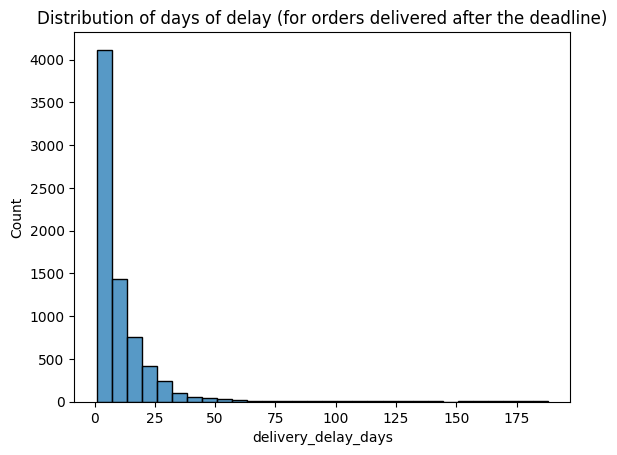

In [12]:
#Creating distribution delay graph
delays_only = br_data[br_data["delivery_delay_days"] > 0]

sns.histplot(delays_only["delivery_delay_days"], bins=30)
plt.title("Distribution of days of delay (for orders delivered after the deadline)")
plt.show()

In [13]:
#Checking freight to price ratio for categories
freight_price_ratio = (
     br_data.assign(freight_ratio = lambda x: (x["freight_value"]/ x["price"]) * 100)
    .groupby("product_category_name")
    .agg(total_orders = ("order_id", "count"), average_freight_ratio = ("freight_ratio", "mean")
    )
)

significant_categories = freight_price_ratio[freight_price_ratio ["total_orders"] > 50]

top_problem_categories = significant_categories.sort_values(by = "average_freight_ratio", ascending = False)

print (top_problem_categories)

                                         total_orders  average_freight_ratio
product_category_name                                                       
dvds_blu_ray                                       61              83.558830
electronics                                      2729              68.389818
christmas_supplies                                150              67.545839
fashion_underwear_beach                           127              55.115639
signaling_and_security                            197              54.998619
telephony                                        4430              50.761258
food_drink                                        269              49.165015
costruction_tools_garden                          232              41.841262
drinks                                            361              41.450850
housewares                                       6795              40.295417
fixed_telephony                                   255              39.522033

In [14]:
br_data.to_csv("olist_cleaned_for_bi.csv", index=False)